In [1]:
%cd ../..

/gpfs/data/schambralab/quantitativeRehabilitation/__lab_member_homes/victor/strokerehab_2025/vlms4rehab


# Results to Latex

In [2]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, List, Optional

import pandas as pd


# ---- helpers ---------------------------------------------------------------

def _safe_float(x: Any) -> Optional[float]:
    """Return float(x) or None if not convertible."""
    try:
        return float(x) if x is not None else None
    except (TypeError, ValueError):
        return None


def _parse_model_args(model_args_str: str) -> Dict[str, str]:
    """
    Parse a 'k=v,k2=v2,...' string into a dict with stripped keys/vals.
    Non 'k=v' chunks are ignored.
    """
    out: Dict[str, str] = {}
    if not model_args_str:
        return out
    for kv in model_args_str.split(","):
        if "=" in kv:
            k, v = kv.split("=", 1)
            out[k.strip()] = v.strip()
    return out


# ---- per-file --------------------------------------------------------------

def extract_eval_row_from_file(file_path: str | Path) -> Optional[Dict[str, Any]]:
    """
    Read one '*_results.json' file and extract a flat row dict.

    Fields produced:
      - file (basename of the JSON file)
      - "edit_score,combine-and-parse"
      - "edit_score_stderr,combine-and-parse"
      - "action_error_rate,combine-and-parse"
      - "action_error_rate_stderr,combine-and-parse"
      - "mae_avg,combine-and-parse"
      - "mae_avg_stderr,combine-and-parse"
      - "prompt" (from configs -> ... -> lmms_eval_specific_kwargs)
      - "use_video_with_segmentations" (same)
      - "total_evaluation_time_seconds" (top level, coerced to float if possible)
      - "max_frames_num" (from parsed config.model_args)
      - "sampling_fps"   (from parsed config.model_args)

    Notes:
      * If the file is unreadable, invalid JSON, or lacks expected blocks, returns None.
      * Automatically picks the (single) task key found under results/configs.

    Parameters
    ----------
    file_path : str | Path

    Returns
    -------
    dict | None
        A single “row” dict, or None if the file cannot be parsed.
    """
    fp = Path(file_path)
    try:
        with fp.open("r") as f:
            data = json.load(f)
    except Exception:
        return None  # unreadable/invalid JSON

    # Extract task blocks (first key under "results" and matching in "configs")
    results_block: Dict[str, Any] = data.get("results", {}) or {}
    task_key: Optional[str] = next(iter(results_block.keys()), None)
    task_obj: Dict[str, Any] = results_block.get(task_key, {}) if task_key else {}

    configs_block: Dict[str, Any] = data.get("configs", {}) or {}
    config_obj: Dict[str, Any] = configs_block.get(task_key, {}) if task_key else {}
    lmms_kwargs: Dict[str, Any] = (config_obj.get("lmms_eval_specific_kwargs") or {}) if isinstance(config_obj, dict) else {}

    total_eval_time = _safe_float(data.get("total_evaluation_time_seconds"))

    model_args_str = ((data.get("config") or {}).get("model_args")) or ""
    parsed_args = _parse_model_args(model_args_str)

    row = {
        "file": fp.name,
        "abs_path": str(fp),
        "edit_score,combine-and-parse": task_obj.get("edit_score,combine-and-parse"),
        "edit_score_stderr,combine-and-parse": task_obj.get("edit_score_stderr,combine-and-parse"),
        "action_error_rate,combine-and-parse": task_obj.get("action_error_rate,combine-and-parse"),
        "action_error_rate_stderr,combine-and-parse": task_obj.get("action_error_rate_stderr,combine-and-parse"),
        "mae_avg,combine-and-parse": task_obj.get("mae_avg,combine-and-parse"),
        "mae_avg_stderr,combine-and-parse": task_obj.get("mae_avg_stderr,combine-and-parse"),
        "prompt": lmms_kwargs.get("prompt"),
        "use_video_with_segmentations": lmms_kwargs.get("use_video_with_segmentations"),
        "total_evaluation_time_seconds": total_eval_time,
        "max_frames_num": parsed_args.get("max_frames_num"),
        "sampling_fps": parsed_args.get("sampling_fps"),
    }
    return row


# ---- per-folder (aggregator) ----------------------------------------------

def collect_eval_results(dir_path: str | Path) -> pd.DataFrame:
    """
    Scan a directory for files named '*_results.json' and produce one row per file.

    This mirrors the behavior of the original function, but delegates per-file
    parsing to `extract_eval_row_from_file`.

    Parameters
    ----------
    dir_path : str | Path
        Directory containing the result JSON files.

    Returns
    -------
    pandas.DataFrame
        One row per JSON file with the requested fields.
    """
    dir_path = Path(dir_path)
    rows: List[Dict[str, Any]] = []

    for fp in sorted(dir_path.glob("**/*_results.json")):
        row = extract_eval_row_from_file(fp)
        if row is not None:
            row["rel_path"] = str(fp.relative_to(dir_path))
            row["folder"] = str(fp.parent.relative_to(dir_path))
            rows.append(row)

    df = pd.DataFrame(rows)

    # Optional: enforce a consistent column order
    desired_cols = [
        "file",
        "edit_score,combine-and-parse",
        "edit_score_stderr,combine-and-parse",
        "action_error_rate,combine-and-parse",
        "action_error_rate_stderr,combine-and-parse",
        "mae_avg,combine-and-parse",
        "mae_avg_stderr,combine-and-parse",
        "prompt",
        "use_video_with_segmentations",
        "total_evaluation_time_seconds",
        "max_frames_num",
        "sampling_fps",
    ]
    # Keep any extra columns at the end (if ever added upstream)
    ordered_cols = [c for c in desired_cols if c in df.columns] + [c for c in df.columns if c not in desired_cols]
    return df.reindex(columns=ordered_cols)


In [3]:
import pandas as pd
import re
import json
import glob
import numpy as np
from typing import Optional
from data.utils_strokerehab import string_to_resps, PrimitiveLabelUtils

PROMPT_MAP = {
    "single_prediction": "SP",
    "single_motion_and_contact": "SMC",
    "ideal": "Ideal"
}

# --- RCE recompute (relative_counting_error is NOT stored in *_results.json, so
#     it is recomputed per-sample from the run's *_samples_*.jsonl, matching
#     counting_all.ipynb / baselines.ipynb). Needs an "abs_path" column. ---
_PRIMS = PrimitiveLabelUtils.PRIMITIVES

def _dedup(xs):
    out = []
    for x in xs:
        if not out or x != out[-1]:
            out.append(x)
    return out

def _rce_mean_sem(abs_results_path):
    """Return (mean, sem) of relative counting error for one run, or (nan, nan)."""
    if not isinstance(abs_results_path, str):
        return (float("nan"), float("nan"))
    matches = glob.glob(abs_results_path.replace("_results.json", "") + "_samples_*.jsonl")
    if not matches:
        return (float("nan"), float("nan"))
    rces = []
    with open(matches[0]) as f:
        for line in f:
            s = json.loads(line)
            pred = _dedup([x.lower() for x in string_to_resps(s["filtered_resps"][0])[0]])
            ref  = _dedup([x.lower() for x in string_to_resps(s["target"])[0]])
            tot = sum(abs(pred.count(p) - ref.count(p)) for p in _PRIMS)
            ct  = sum(ref.count(p) for p in _PRIMS)
            rces.append(tot / ct if ct else 0.0)
    n = len(rces)
    if n == 0:
        return (float("nan"), float("nan"))
    sem = float(np.std(rces, ddof=1) / np.sqrt(n)) if n > 1 else 0.0
    return (float(np.mean(rces)), sem)


def _pm(val: Optional[float], err: Optional[float], fmt: str = "{:.2f}") -> str:
    """Return 'val ± err' (both formatted) or '–' if val is missing."""
    val = float(val) if not pd.isna(val) else val
    err = float(err) if not pd.isna(err) else err
    if pd.isna(val):
        return "–"
    s = fmt.format(val)
    try:
        return f"{s} ± {fmt.format(err)}"
    except Exception:
        return f"{s} ± {err}"
    # if pd.isna(err) or (err == 0):
    #     return s
    # return f"{s} ± {fmt.format(err)}"

def _fmt_runtime(seconds: Optional[float]) -> str:
    """Format seconds as H:MM:SS (or '–' if missing)."""
    if pd.isna(seconds):
        return "–"
    seconds = float(seconds)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = int(round(seconds % 60))
    return f"{h}:{m:02d}:{s:02d}"

def make_results_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a display DataFrame with columns:
    FPS | Frames | Prompt | ES | AER | RCE | Run time
    (ES/AER shown as 'mean ± stderr' from the stored aggregate; RCE recomputed
    per-sample from each run's *_samples_*.jsonl via _rce_mean_sem)
    """
    abs_paths = df.get("abs_path", pd.Series([None] * len(df)))
    rce_pairs = [_rce_mean_sem(ap) for ap in abs_paths]
    out = pd.DataFrame({
        "_file": df.get("file"),
        "FPS": pd.to_numeric(df.get("sampling_fps"), errors="coerce"),
        "Frames": pd.to_numeric(df.get("max_frames_num"), errors="coerce"),
        "Prompt": df.get("prompt").map(PROMPT_MAP).fillna(df.get("prompt")),
        "ES": [
            _pm(v, e) for v, e in zip(
                df.get("edit_score,combine-and-parse"),
                df.get("edit_score_stderr,combine-and-parse"),
            )
        ],
        "AER": [
            _pm(v, e) for v, e in zip(
                df.get("action_error_rate,combine-and-parse"),
                df.get("action_error_rate_stderr,combine-and-parse"),
            )
        ],
        "RCE": [_pm(m, e) for (m, e) in rce_pairs],
        "Run time": df.get("total_evaluation_time_seconds").map(_fmt_runtime),
    })

    columns_so_far = ["file", "abs_path", "sampling_fps", "max_frames_num", "prompt",
                      "edit_score,combine-and-parse", "edit_score_stderr,combine-and-parse",
                      "action_error_rate,combine-and-parse", "action_error_rate_stderr,combine-and-parse",
                      "mae_avg,combine-and-parse", "mae_avg_stderr,combine-and-parse",
                      "total_evaluation_time_seconds"
    ]
    columns_remaining = [c for c in df.columns if c not in columns_so_far]
    for c in columns_remaining:
        out[c] = df[c]

    # Sort by window size
    out["Inverse Window Size"] = (out["FPS"] / out["Frames"]).map(lambda x: int(round(x)))

    out = out.sort_values(["Inverse Window Size"], kind="stable", na_position="last").reset_index(drop=True)
    # Rename
    out.rename(columns={"Inverse Window Size": "$1/d$ (rounded)", "FPS": "$f$", "Frames": "$n$"}, inplace=True)
    return out


def _wrap_best(cell: str, rank: int) -> str:
    """
    rank=0 -> best (green), rank=1 -> second-best (blue), otherwise unchanged.
    """
    if rank == 0:
        return r"\cellcolor{green!20}\textbf{" + cell + "}"
    if rank == 1:
        return r"\cellcolor{blue!20}\textbf{" + cell + "}"
    return cell


def apply_best_second_styling(table_df: pd.DataFrame) -> pd.DataFrame:
    """
    Color + bold the best (green) and second-best (blue) for ES/AER/RCE.
    Works directly from table_df where metrics look like '40.27 ± 1.69'.
    Requires `_wrap_best` defined elsewhere.
    """
    styled = table_df.copy()

    def _extract_val(s: str) -> float | None:
        """Extract the numeric value before '±' (or full string if plain number)."""
        if pd.isna(s):
            return None
        m = re.match(r"^\s*([+-]?\d+(?:\.\d+)?)", str(s))
        return float(m.group(1)) if m else None

    metric_specs = [
        ("ES",  True),   # higher is better
        ("AER", False),  # lower is better
        ("RCE", False),  # lower is better
    ]

    for colname, higher_is_better in metric_specs:
        vals = table_df[colname].map(_extract_val)

        # drop NAs but preserve index alignment
        valid = vals.dropna()
        if valid.empty:
            continue

        # sort by metric, respecting higher/lower is better
        sorted_idx = valid.sort_values(ascending=not higher_is_better).index.tolist()

        best_idx = sorted_idx[0]
        second_idx = sorted_idx[1] if len(sorted_idx) > 1 else None

        styled.loc[best_idx, colname] = _wrap_best(styled.loc[best_idx, colname], rank=0)
        if second_idx is not None:
            styled.loc[second_idx, colname] = _wrap_best(styled.loc[second_idx, colname], rank=1)

    return styled



def results_table_to_latex(table_df: pd.DataFrame) -> str:
    """
    Convert to LaTeX with arrows in metric headers.
    Requires: \\usepackage{booktabs} and \\usepackage[table]{xcolor} in your preamble.
    """
    # rename headers with arrows
    renamed = table_df.rename(columns={
        "ES":  "ES $\\uparrow$",
        "AER": "AER $\\downarrow$",
        "RCE": "RCE $\\downarrow$",
    }).drop(columns=["_file"], errors="ignore")

    col_format = "rrlccc r".replace(" ", "")  # 'rrlcccr'
    return renamed.to_latex(index=False, escape=False, column_format=col_format)

In [4]:
# (f, n) sampling-sweep ablations are Qwen2.5-VL-32B (copied from naveen/cvfm4rehab/logs).
path_2 = "logs/ablation_direct_primitives_2"        # single_prediction         -> Table C (Direct)
spdf = collect_eval_results(path_2)
path_3 = "logs/ablation_decomposed_primitives_3"    # single_motion_and_contact -> Table D (Decomposed)
smcdf = collect_eval_results(path_3)
# 'ideal'-prompt sweep exists only for qwen2_5_vl_7b (no 32B 'ideal' run); these logs stay gitignored.
path_1 = "logs/strokerehab_primitives_1/qwen2_5_vl_7b/Qwen__Qwen2.5-VL-7B-Instruct"
idf = collect_eval_results(path_1)

In [5]:
df = pd.concat([idf, spdf], ignore_index=True)
df['max_frames_num'] = df['max_frames_num'].astype(int)
df['sampling_fps'] = df['sampling_fps'].astype(int)

ideal_fn_filter = (
    ((df['sampling_fps'] == 1) & (df['max_frames_num'] == 1)) |
    ((df['sampling_fps'] == 2) & (df['max_frames_num'] == 2)) |
    ((df['sampling_fps'] == 2) & (df['max_frames_num'] == 1)) |
    ((df['sampling_fps'] == 4) & (df['max_frames_num'] == 2)) |
    ((df['sampling_fps'] == 4) & (df['max_frames_num'] == 1)) |
    ((df['sampling_fps'] == 8) & (df['max_frames_num'] == 1)) |
    ((df['sampling_fps'] == 8) & (df['max_frames_num'] == 8)) |
    ((df['sampling_fps'] == 4) & (df['max_frames_num'] == 8)) |
    ((df['sampling_fps'] == 2) & (df['max_frames_num'] == 8)) |
    ((df['sampling_fps'] == 15) & (df['max_frames_num'] == 15)) |
    ((df['sampling_fps'] == 8) & (df['max_frames_num'] == 15)) |
    ((df['sampling_fps'] == 4) & (df['max_frames_num'] == 15))
)
df = df[ideal_fn_filter]
tbl = make_results_table(df)
tbl = tbl[["_file", "$1/d$ (rounded)", "$f$", "$n$", "Prompt", "ES", "AER", "RCE", "Run time"]].copy()
tbl.drop(columns=["Run time"], inplace=True)
tbl_styled = apply_best_second_styling(tbl)
latex = results_table_to_latex(tbl_styled)
print(latex)

\begin{tabular}{rrlcccr}
\toprule
$1/d$ (rounded) & $f$ & $n$ & Prompt & ES $\uparrow$ & AER $\downarrow$ & RCE $\downarrow$ \\
\midrule
0 & 4 & 8 & Ideal & 25.91 ± 1.49 & 2.38 ± 0.24 & 2.63 ± 0.25 \\
0 & 4 & 15 & Ideal & 35.45 ± 1.67 & 1.20 ± 0.14 & 1.44 ± 0.14 \\
1 & 1 & 1 & Ideal & 20.54 ± 1.31 & 3.94 ± 0.35 & 4.12 ± 0.36 \\
1 & 2 & 2 & Ideal & 19.29 ± 1.20 & 4.24 ± 0.39 & 4.42 ± 0.40 \\
1 & 8 & 8 & Ideal & 17.09 ± 1.06 & 4.71 ± 0.45 & 4.91 ± 0.46 \\
1 & 8 & 15 & Ideal & 25.47 ± 1.43 & 2.42 ± 0.26 & 2.66 ± 0.26 \\
1 & 15 & 15 & Ideal & 16.15 ± 1.04 & 5.13 ± 0.50 & 3.27 ± 0.33 \\
1 & 1 & 1 & SP & 41.83 ± 1.01 & 0.65 ± 0.04 & 0.65 ± 0.04 \\
1 & 2 & 2 & SP & 41.25 ± 1.07 & \cellcolor{blue!20}\textbf{0.64 ± 0.02} & \cellcolor{blue!20}\textbf{0.64 ± 0.03} \\
1 & 8 & 8 & SP & 40.40 ± 1.21 & 0.65 ± 0.03 & 0.64 ± 0.03 \\
1 & 15 & 15 & SP & 41.86 ± 1.20 & \cellcolor{green!20}\textbf{0.61 ± 0.02} & \cellcolor{green!20}\textbf{0.63 ± 0.03} \\
2 & 2 & 1 & Ideal & 10.83 ± 0.74 & 8.59 ± 0.71 & 8.

In [6]:
tbl_spdf = make_results_table(spdf)
tbl_spdf = tbl_spdf[["_file", "$1/d$ (rounded)", "$f$", "$n$", "Prompt", "ES", "AER", "RCE", "Run time"]].copy()
tbl_spdf.drop(columns=['Prompt'], inplace=True)
tbl_styled = apply_best_second_styling(tbl_spdf)
latex = results_table_to_latex(tbl_styled)
print(latex)

\begin{tabular}{rrlcccr}
\toprule
$1/d$ (rounded) & $f$ & $n$ & ES $\uparrow$ & AER $\downarrow$ & RCE $\downarrow$ & Run time \\
\midrule
1 & 30 & 30 & 40.39 ± 1.24 & 0.63 ± 0.02 & 0.68 ± 0.02 & 10:25:47 \\
1 & 1 & 1 & 41.83 ± 1.01 & 0.65 ± 0.04 & 0.65 ± 0.04 & 0:54:44 \\
1 & 2 & 2 & 41.25 ± 1.07 & 0.64 ± 0.02 & 0.64 ± 0.03 & 0:57:15 \\
1 & 8 & 8 & 40.40 ± 1.21 & 0.65 ± 0.03 & 0.64 ± 0.03 & 2:40:31 \\
1 & 4 & 4 & 41.87 ± 1.19 & \cellcolor{blue!20}\textbf{0.62 ± 0.02} & \cellcolor{green!20}\textbf{0.60 ± 0.03} & 1:35:06 \\
1 & 15 & 15 & 41.86 ± 1.20 & \cellcolor{green!20}\textbf{0.61 ± 0.02} & \cellcolor{blue!20}\textbf{0.63 ± 0.03} & 5:42:49 \\
2 & 2 & 1 & 44.24 ± 1.01 & 0.81 ± 0.08 & 0.82 ± 0.08 & 1:50:34 \\
2 & 15 & 8 & \cellcolor{green!20}\textbf{46.34 ± 0.97} & 0.69 ± 0.05 & 0.71 ± 0.05 & 5:25:54 \\
2 & 30 & 15 & 43.73 ± 1.09 & 0.72 ± 0.05 & 0.77 ± 0.05 & 11:11:41 \\
2 & 4 & 2 & 44.92 ± 1.00 & 0.82 ± 0.06 & 0.81 ± 0.06 & 1:51:02 \\
2 & 8 & 4 & \cellcolor{blue!20}\textbf{45.70 ± 1.

In [7]:
df = pd.concat([spdf, smcdf], ignore_index=True)
tbl = make_results_table(df)
tbl = tbl[["_file", "$1/d$ (rounded)", "$f$", "$n$", "Prompt", "ES", "AER", "RCE", "Run time"]].copy()
remove_filter = (
    tbl["$1/d$ (rounded)"].isin([0, 1])
)
tbl = tbl[~remove_filter]

tbl_styled = apply_best_second_styling(tbl)
latex = results_table_to_latex(tbl_styled)
print(latex)

\begin{tabular}{rrlcccr}
\toprule
$1/d$ (rounded) & $f$ & $n$ & Prompt & ES $\uparrow$ & AER $\downarrow$ & RCE $\downarrow$ & Run time \\
\midrule
2 & 2 & 1 & SP & 44.24 ± 1.01 & 0.81 ± 0.08 & 0.82 ± 0.08 & 1:50:34 \\
2 & 15 & 8 & SP & 46.34 ± 0.97 & 0.69 ± 0.05 & 0.71 ± 0.05 & 5:25:54 \\
2 & 30 & 15 & SP & 43.73 ± 1.09 & 0.72 ± 0.05 & 0.77 ± 0.05 & 11:11:41 \\
2 & 4 & 2 & SP & 44.92 ± 1.00 & 0.82 ± 0.06 & 0.81 ± 0.06 & 1:51:02 \\
2 & 8 & 4 & SP & 45.70 ± 1.02 & 0.69 ± 0.04 & 0.68 ± 0.04 & 2:56:60 \\
2 & 15 & 8 & SMC & 46.69 ± 1.62 & \cellcolor{blue!20}\textbf{0.65 ± 0.06} & \cellcolor{blue!20}\textbf{0.65 ± 0.06} & 6:03:12 \\
2 & 30 & 15 & SMC & \cellcolor{blue!20}\textbf{49.21 ± 1.39} & \cellcolor{green!20}\textbf{0.64 ± 0.08} & \cellcolor{green!20}\textbf{0.65 ± 0.08} & 12:00:50 \\
2 & 2 & 1 & SMC & 42.80 ± 1.64 & 0.73 ± 0.08 & 0.73 ± 0.08 & 2:01:51 \\
2 & 4 & 2 & SMC & 40.68 ± 1.74 & 0.74 ± 0.08 & 0.75 ± 0.08 & 2:05:37 \\
2 & 8 & 4 & SMC & 44.16 ± 1.75 & 0.71 ± 0.08 & 0.70 ± 0.08 

## LLMs Ablation

In [8]:
import datetime as dt
import re

def extract_timestamp_from_filename(fname: str) -> dt.datetime | None:
    m = re.match(r"(\d{8}_\d{6})", fname)
    if not m:
        return None
    try:
        return dt.datetime.strptime(m.group(1), "%Y%m%d_%H%M%S")
    except ValueError:
        return None


In [9]:
all_results = collect_eval_results("logs/strokerehab_primitives_3_all_models/")
all_results['date'] = all_results['file'].map(extract_timestamp_from_filename)
all_results = all_results[~all_results['folder'].isin(['longva_7b'])]   # extra, not in Table 4
latest_results = all_results.groupby(['folder']).first()

In [10]:


tbl = make_results_table(latest_results)

tbl['samples_path'] = tbl['rel_path']\
    .apply(lambda s: s.replace("_results.json", "_samples_strokerehab_primitives_3.jsonl"))
tbl['model'] = tbl['rel_path'].apply(lambda s: s.split('/')[0])
def extract_model_and_size(s: str) -> tuple[str, float]:
    try:
        size_start_idx = -1
        size = float(s.split('_')[size_start_idx][:-1].replace('p', '.'))
    except ValueError:
        size_start_idx = -2
        size = float(s.split('_')[size_start_idx][:-1].replace('p', '.'))
    model_family = '_'.join(s.split('_')[0:size_start_idx])
    return model_family, size
tbl[['model_family', 'model_size']] = tbl['model'].apply(
    lambda s: pd.Series(extract_model_and_size(s))
)
tbl.sort_values(by=['model_family', 'model_size'], inplace=True)
tbl.drop(columns=['model_family', 'model_size'], inplace=True)
tbl['model'] = tbl['model'].apply(lambda s: s.replace('_', r'\_'))
tbl['samples_path'] = tbl['rel_path']\
    .apply(lambda s: s.replace("_results.json", "_samples_strokerehab_primitives_3.jsonl"))


In [11]:
# --- RCE version of the model-zoo table (recompute ES/AER/RCE per-sample) ---
import os, json, numpy as np, pandas as pd
from data.utils_strokerehab import string_to_resps, PrimitiveLabelUtils
try:
    from Levenshtein import distance as _lev
except ImportError:
    _lev = None

_PRIMS = PrimitiveLabelUtils.PRIMITIVES
def _dedup(xs):
    out = []
    for x in xs:
        if not out or x != out[-1]: out.append(x)
    return out
def _levenshtein(a, b):
    if _lev: return _lev(a, b)
    dp = list(range(len(b)+1))
    for i in range(1, len(a)+1):
        prev, dp[0] = dp[0], i
        for j in range(1, len(b)+1):
            prev, dp[j] = dp[j], prev if a[i-1]==b[j-1] else 1+min(prev, dp[j], dp[j-1])
    return dp[-1]
def _sample_metrics(filtered, target):
    pred = _dedup([p.lower() for p in string_to_resps(filtered)[0]])
    ref  = _dedup([p.lower() for p in string_to_resps(target)[0]])
    ml = max(len(pred), len(ref)); ed = _levenshtein(pred, ref) if ml else 0
    es  = 100.0 if ml == 0 else (1 - ed/ml)*100.0
    aer = ed/len(ref) if ref else 0.0
    tot = sum(abs(pred.count(p)-ref.count(p)) for p in _PRIMS)
    ct  = sum(ref.count(p) for p in _PRIMS)
    rce = tot/ct if ct else 0.0
    return es, aer, rce
def _agg(path):
    with open(path) as f: S = [json.loads(l) for l in f]
    M = np.array([_sample_metrics(s["filtered_resps"][0], s["target"]) for s in S])
    return M.mean(0), M.std(0, ddof=1)/np.sqrt(len(M))   # (es,aer,rce) mean, sem

ROOT = "logs/strokerehab_primitives_3_all_models"        # samples_path is relative to this dir
rows = []
for _, r in tbl.iterrows():
    (es, aer, rce), (es_e, aer_e, rce_e) = _agg(os.path.join(ROOT, r["samples_path"]))
    rows.append({"Model": r["model"], "ES": _pm(es, es_e),
                 "AER": _pm(aer, aer_e), "RCE": _pm(rce, rce_e)})
zoo = pd.DataFrame(rows)

def _style(df):                                 # green=best, blue=second (per column)
    s = df.copy()
    for col, higher_better in [("ES", True), ("AER", False), ("RCE", False)]:
        v = df[col].str.extract(r"^\s*([+-]?\d+\.?\d*)")[0].astype(float)
        order = v.sort_values(ascending=not higher_better).index.tolist()
        s.loc[order[0], col] = _wrap_best(s.loc[order[0], col], 0)
        if len(order) > 1: s.loc[order[1], col] = _wrap_best(s.loc[order[1], col], 1)
    return s

latex = (_style(zoo)
    .rename(columns={"ES": "ES $\\uparrow$", "AER": "AER $\\downarrow$", "RCE": "RCE $\\downarrow$"})
    .to_latex(index=False, escape=False, column_format="lccc"))
print(latex)


\begin{tabular}{lccc}
\toprule
Model & ES $\uparrow$ & AER $\downarrow$ & RCE $\downarrow$ \\
\midrule
internvl3\_78b & \cellcolor{green!20}\textbf{49.83 ± 1.21} & 0.68 ± 0.09 & 0.73 ± 0.09 \\
internvl3p5\_2b & 34.20 ± 1.98 & 0.81 ± 0.12 & 0.80 ± 0.12 \\
internvl3p5\_8b & 8.17 ± 1.24 & 0.92 ± 0.01 & 0.93 ± 0.01 \\
internvl3p5\_30b\_a3b & 25.54 ± 1.94 & 0.78 ± 0.02 & 0.87 ± 0.03 \\
internvl3p5\_38b & 40.20 ± 1.49 & 0.68 ± 0.03 & 0.80 ± 0.03 \\
llava\_next\_video\_7b & 46.18 ± 1.76 & \cellcolor{blue!20}\textbf{0.65 ± 0.07} & 0.68 ± 0.07 \\
llava\_next\_video\_72b & 23.08 ± 1.65 & 0.78 ± 0.02 & 0.97 ± 0.03 \\
llava\_ov\_0p5b & 20.97 ± 1.44 & 0.80 ± 0.01 & 0.96 ± 0.02 \\
llava\_ov\_7b & 42.07 ± 1.31 & 0.69 ± 0.04 & 0.78 ± 0.05 \\
llava\_ov\_72b & 38.52 ± 1.93 & 0.72 ± 0.07 & 0.76 ± 0.08 \\
longva\_7b & 5.03 ± 1.14 & 0.95 ± 0.01 & 0.95 ± 0.01 \\
nvila\_8b & 36.98 ± 2.09 & 0.75 ± 0.09 & 0.76 ± 0.09 \\
nvila\_15b & 24.92 ± 1.21 & 0.79 ± 0.04 & 0.95 ± 0.04 \\
qwen2\_5\_vl\_7b & 34.75 ± 1.73 & 

# Further Analysis
RUN THE SECTION ABOVE.

In [12]:
from __future__ import annotations

import json
import gzip
from pathlib import Path
from typing import Iterable, Dict, Any, List

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import math
import html
import io
from typing import List, Dict, Tuple, Optional, Union, Literal

import numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont


def _iter_jsonl(path: Path) -> Iterable[Dict[str, Any]]:
    """
    Stream a .jsonl or .jsonl.gz file, yielding parsed JSON objects line by line.
    Skips blank lines; raises on unrecoverable JSON errors.
    """
    opener = gzip.open if path.suffix == ".gz" or path.suffixes[-2:] == [".jsonl", ".gz"] else open
    mode = "rt"  # text mode
    with opener(path, mode, encoding="utf-8") as f:
        for ln, line in enumerate(f, start=1):
            s = line.strip()
            if not s:
                continue
            try:
                yield json.loads(s)
            except json.JSONDecodeError as e:
                raise ValueError(f"JSON decode error in {path} at line {ln}: {e}") from e


def explode_samples_from_jsonl_paths(
    latest_results_table: pd.DataFrame,
    path_col: str = "samples_path",
    log_dir: str | Path = "logs/strokerehab_primitives_3_all_models/"
) -> pd.DataFrame:
    """
    For each JSONL pointed to by `latest_results_table[path_col]`, read every example (one per line)
    and extract: `id`, `target`, and `filtered_resps`.

    Returns a DataFrame that contains all columns from `latest_results_table`
    plus the exploded per-sample fields: [id, target, filtered_resps, edit_score, action_error_rate, mae_avg].

    Notes
    -----
    - `id` is taken from item['doc']['id'] if present, otherwise item['id'].
    - `filtered_resps` is returned as-is (often a string or a list of strings).
    - Supports both .jsonl and .jsonl.gz files.
    """
    if path_col not in latest_results_table.columns:
        raise KeyError(f"`{path_col}` column not found in latest_results_table.")

    rows: List[Dict[str, Any]] = []

    for _, row in latest_results_table.iterrows():
        p = row[path_col]
        if p is None or (isinstance(p, float) and pd.isna(p)):
            continue
        path = Path(log_dir) / p
        if not path.exists():
            raise FileNotFoundError(f"File not found: {path}")

        for item in _iter_jsonl(path):
            doc = item.get("doc", {})
            ex_id = doc.get("id", item.get("id"))

            target = item.get("target")
            filtered_resps = item.get("filtered_resps")
            if isinstance(filtered_resps, list) and len(filtered_resps) == 1:
                filtered_resps = filtered_resps[0]

            rows.append(
                {
                    **row.to_dict(),  # keep all original columns
                    "samples_path": str(path),
                    "id": ex_id,
                    "target": target,
                    "filtered_resps": filtered_resps,
                    "edit_score": item.get("edit_score"),
                    "action_error_rate": item.get("action_error_rate"),
                    "mae_avg": item.get("mae_avg"),
                }
            )

    return pd.DataFrame(rows)




def _parse_segments(seq: str):
    """
    Parse strings like 'idle@0.000;reach@0.917;transport@1.550;...' into
    list of dicts with {'action': str, 't': float}.
    """
    parts = seq.split(";")
    segs = []
    for p in parts:
        if not p.strip():
            continue
        try:
            action, t = p.split("@")
            segs.append({"action": action.strip(), "t": float(t)})
        except ValueError:
            continue
    return segs


def _segments_to_intervals(segs):
    """
    Given [{'action': a, 't': t}, ...] sorted by t, produce intervals
    [{'action': a, 't0': t0, 't1': t1}, ...]
    """
    intervals = []
    for i, s in enumerate(segs):
        t0 = s["t"]
        t1 = segs[i + 1]["t"] if i + 1 < len(segs) else t0
        intervals.append({"action": s["action"], "t0": t0, "t1": t1})
    return intervals


def _to_intervals_up_to_duration(seq: str, duration: float):
    segs = _parse_segments(seq)
    if not segs:
        return []
    ivals = []
    for i, s in enumerate(segs):
        t0 = s["t"]
        t1 = segs[i+1]["t"] if i+1 < len(segs) else duration
        # clip & keep only positive spans
        t0c, t1c = max(0.0, min(t0, duration)), max(0.0, min(t1, duration))
        if t1c > t0c:
            ivals.append({"action": s["action"], "t0": t0c, "t1": t1c})
    return ivals

def row_accuracy(row) -> float:
    tgt_segs = _parse_segments(row["target"])
    if not tgt_segs:
        return np.nan
    duration = tgt_segs[-1]["t"]  # “The last time of the target is the video's duration.”

    tgt = _to_intervals_up_to_duration(row["target"], duration)
    pred = _to_intervals_up_to_duration(row["filtered_resps"], duration)
    if not pred or not tgt or duration <= 0:
        return 0.0

    i = j = 0
    match_time = 0.0
    while i < len(tgt) and j < len(pred):
        a, b = tgt[i], pred[j]
        start = max(a["t0"], b["t0"])
        end   = min(a["t1"], b["t1"])
        if end > start and a["action"] == b["action"]:
            match_time += (end - start)
        # advance whichever interval ends first (both if tie)
        if a["t1"] <= b["t1"]:
            i += 1
        if b["t1"] <= a["t1"]:
            j += 1

    return match_time / duration


# ----------------------------
# Shared helpers
# ----------------------------
_DEFAULT_PALETTE: List[Tuple[int, int, int]] = [
    (230, 25, 75),   # red
    (60, 180, 75),   # green
    (0, 130, 200),   # blue
    (245, 130, 48),  # orange
    (145, 30, 180),  # purple
    (70, 240, 240),  # cyan
    (240, 50, 230),  # magenta
    (210, 245, 60),  # lime
    (250, 190, 190), # pink
    (0, 128, 128),   # teal
    (170, 110, 40),  # brown
    (255, 225, 25),  # yellow
]

def _rgb_hex(rgb: Tuple[int, int, int]) -> str:
    r, g, b = rgb
    return f"#{r:02x}{g:02x}{b:02x}"

def _infer_actions_in_order(label_segments: List[Dict]) -> List[str]:
    seen, order = set(), []
    for s in label_segments:
        a = s["action"]
        if a not in seen:
            seen.add(a)
            order.append(a)
    return order

def _ensure_color_map(actions_in_order: List[str],
                      color_map: Optional[Dict[str, Tuple[int, int, int]]]) -> Dict[str, Tuple[int, int, int]]:
    if color_map is None:
        return {a: _DEFAULT_PALETTE[i % len(_DEFAULT_PALETTE)] for i, a in enumerate(actions_in_order)}
    # validate provided map
    for a in actions_in_order:
        if a not in color_map:
            raise KeyError(f"'{a}' missing from color_map")
        r, g, b = color_map[a]
        for c in (r, g, b):
            if not (isinstance(c, int) and 0 <= c <= 255):
                raise ValueError(f"Invalid RGB value {color_map[a]} for '{a}'")
    return color_map

def plot_bars_for_df(df, color_map=None):
    """
    Draw one plot per ID:
      - Top row: target (ground truth, assumed same across df)
      - Subsequent rows: filtered_resps (one per model)
    """
    if len(df) == 0:
        return
    
    assert df['id'].nunique() == 1, f"Expected 1 id, got: {df['id'].unique()}"

    id_val = df.iloc[0]['id']
    target_segs = _parse_segments(df.iloc[0]["target"])
    target_ints = _segments_to_intervals(target_segs)

    preds = []
    all_ints = target_ints.copy()
    for _, row in df.iterrows():
        pred_segs = _parse_segments(row["filtered_resps"])
        pred_ints = _segments_to_intervals(pred_segs)
        preds.append((row['model'], pred_ints))
        all_ints.extend(pred_ints)

    actions = _infer_actions_in_order(all_ints)
    cmap = _ensure_color_map(actions, color_map)

    nrows = 1 + len(preds)
    bar_height = 0.9  # fill almost all vertical slot

    fig, ax = plt.subplots(figsize=(12, 0.4 * nrows), constrained_layout=True)

    # Plot target
    for iv in target_ints:
        ax.barh(
            y=0, left=iv["t0"], width=iv["t1"] - iv["t0"],
            height=bar_height, color=_rgb_hex(cmap[iv["action"]]), edgecolor="black"
        )

    # Plot preds
    for i, (model, pred_ints) in enumerate(preds, start=1):
        for iv in pred_ints:
            ax.barh(
                y=i, left=iv["t0"], width=iv["t1"] - iv["t0"],
                height=bar_height, color=_rgb_hex(cmap[iv["action"]]), edgecolor="black"
            )

    ax.set_yticks(range(nrows))
    labels = ["target"] + [m.replace('\\', '') for m, _ in preds]
    edit_scores = [""] + [f"(ES={row['edit_score']:.2f})" for _, row in df.iterrows()]
    action_error_rates = [""] + [f"(AER={row['action_error_rate']:.2f})" for _, row in df.iterrows()]
    ax.set_yticklabels([f"{l} {es} {aer}" for l, es, aer in zip(labels, edit_scores, action_error_rates)])
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{id_val}")

    handles = [mpatches.Patch(color=_rgb_hex(cmap[a]), label=a) for a in actions]
    ax.legend(
        handles=handles,
        bbox_to_anchor=(1.01, 1),   # push just outside right edge
        loc="upper left",
        fontsize=8,
        frameon=False
    )
    # fig.subplots_adjust(right=0.8)

    # Key trick: eliminate white space between bars
    ax.set_ylim(-0.5, nrows - 0.5)
    ax.margins(y=0)

    return fig

In [13]:
df = explode_samples_from_jsonl_paths(tbl, path_col='samples_path')
df.drop(columns=['_file', '$f$', '$n$', 'Prompt', 'ES', 'AER', 'RCE', 'Run time',
       'use_video_with_segmentations', 'rel_path', 'date', '$1/d$ (rounded)',
       'samples_path'], inplace=True)
# df.set_index(['model', 'id'], inplace=True)

# Examining Qwen2.5-VL-32b (SMC, fps=15, n=8)

In [14]:
import json, re
from typing import Any, Dict, Iterable, List, Tuple
import pandas as pd

def samples_to_dataframes(samples: List[Dict[str, Any]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    wanted = ["id","patient","activity","duration_s","target","path_l","path_v",
              "filtered_resps","stroke","edit_score","action_error_rate"]

    def flat_triplets(x: Any) -> Iterable[Tuple[str,str,str]]:
        if isinstance(x, list):
            if len(x)==3 and all(isinstance(x[i], str) for i in range(3)): yield x[0],x[1],x[2]
            else:
                for y in x: yield from flat_triplets(y)

    def split_ans(s: str) -> tuple[str | None, str | None]:
        """Split answers like 'YES <SEP> NO' or 'hi yes yes' into two parts."""
        if not isinstance(s, str):
            return None, None
        parts = [p.strip() for p in s.split("<SEP>")]
        if len(parts) == 2:
            return parts[0], parts[1]
        toks = re.findall(r"\b(yes|no)\b", s.lower())
        if len(toks) >= 2:
            return toks[0].upper(), toks[1].upper()
        if len(toks) == 1:
            return toks[0].upper(), None
        return None, None

    def a2m(a: str | None) -> bool | None:
        a = a.lower().strip()
        if a == "reach" or a == "transport" or a == "reposition":
            return True
        if a == "idle" or a == "stabilize":
            return False
        raise ValueError(f"Unknown motion answer: {a}")

    def a2g(a: str | None) -> bool | None:
        a = a.lower().strip()
        if a == "transport" or a == "stabilize":
            return True
        if a == "idle" or a == "reach" or a == "reposition":
            return False
        raise ValueError(f"Unknown grasp answer: {a}")


    rows, segs = [], []
    for s in samples:
        d = {k: (s.get(k, s.get("doc",{}).get(k))) for k in wanted}
        fr = d.get("filtered_resps")
        d["filtered_resps"] = ";".join(fr) if isinstance(fr, list) else (fr or "")
        d["resps_json"] = json.dumps(s.get("resps", None), ensure_ascii=False)
        if "input" in s: d["prompt_input"] = s["input"]
        rows.append(d)

        sid = d["id"]
        for i,(a,t0,t1) in enumerate(flat_triplets(s.get("resps", []))):
            m,g = split_ans(a)
            try: t0f=float(t0)
            except: t0f=None
            try: t1f=float(t1)
            except: t1f=None
            segs.append({
                "id": sid, "segment_idx": i, "t0": t0f, "t1": t1f,
                "dt": (t1f-t0f) if (t0f is not None and t1f is not None) else None,
                "answer_raw": a,
                "motion_pred": a2m(a), "grasp_pred": a2g(a)
            })

    df_samples, df_resps = pd.DataFrame(rows), pd.DataFrame(segs)
    if not df_samples.empty:
        df_samples["duration_s"] = pd.to_numeric(df_samples["duration_s"], errors="coerce")
        for c in ("edit_score","action_error_rate"):
            if c in df_samples: df_samples[c]=pd.to_numeric(df_samples[c], errors="coerce")
        if "stroke" in df_samples: df_samples["stroke"] = df_samples["stroke"].astype("boolean")
    if not df_resps.empty:
        for c in ("t0","t1","dt"): df_resps[c]=pd.to_numeric(df_resps[c], errors="coerce")
    return df_samples, df_resps

In [15]:
paths = {
    "crop": "logs_qwen2_5_sig_gen_final/20251104_095353_samples_strokerehab_primitives_3.jsonl",
    "crop/cp": "logs/strokerehab_primitives_3/qwen2_5_vl_signal_generator/20251109_002159_samples_strokerehab_primitives_3.jsonl",
    "cp": "logs_qwen2_5_sig_gen_final/20251105_054016_samples_strokerehab_primitives_3.jsonl",
    "baseline": "logs_qwen2_5_sig_gen_final/20251105_082430_samples_strokerehab_primitives_3.jsonl",
}
def log_to_df(logfile):
    with open(logfile, 'r') as f:
        lines = f.readlines()
    import json
    samples = [json.loads(line) for line in lines]
    return samples_to_dataframes(samples)

dfs = {key: log_to_df(value) for key, value in paths.items()}

dfs['crop'][1].head()

,id,segment_idx,t0,t1,dt,answer_raw,motion_pred,grasp_pred
0,S00011_RTT right side1_1,0,0.000,0.533,0.533,idle,False,False
1,S00011_RTT right side1_1,1,0.533,1.067,0.534,idle,False,False
2,S00011_RTT right side1_1,2,1.067,1.600,0.533,transport,True,True
3,S00011_RTT right side1_1,3,1.600,2.133,0.533,transport,True,True
4,S00011_RTT right side1_1,4,2.133,2.667,0.534,transport,True,True


In [17]:
from lmms_eval.tasks.strokerehab.utils_primitives import _get_primitives_score

def get_metrics_for_row(row):
    target = row['target']
    predicted = row['filtered_resps']

    target = [x['action'].lower().strip() for x in _parse_segments(target)]
    predicted = [x['action'].lower().strip() for x in _parse_segments(predicted)]
    score = _get_primitives_score(predicted, target)

    mae_total = sum([score[f'mae_{p}'] for p in ['idle', 'reach', 'transport', 'reposition', 'stabilize']])
    count_total = score['count_truth']

    metrics = {
        'edit_score': score['edit_score'],
        'action_error_rate': score['action_error_rate'],
        'relative_counting_error': mae_total / count_total
    }
    return metrics

In [18]:
key2metrics = {}

for key, (df_samples, _) in dfs.items():
    metrics = df_samples.apply(get_metrics_for_row, axis=1, result_type='expand')
    df_samples[['edit_score', 'action_error_rate', 'relative_counting_error']] = metrics

    metrics = {
        "edit_score": np.mean(df_samples["edit_score"]),
        "edit_score_std":  np.std(df_samples["edit_score"], ddof=1) / np.sqrt(len(df_samples)),
        "action_error_rate":        np.mean(df_samples["action_error_rate"]),
        "action_error_rate_std":         np.std(df_samples["action_error_rate"], ddof=1) / np.sqrt(len(df_samples)),
        "relative_counting_error":        np.mean(df_samples["relative_counting_error"]),
        "relative_counting_error_std":         np.std(df_samples["relative_counting_error"], ddof=1) / np.sqrt(len(df_samples)),
    }
    key2metrics[key] = metrics

In [19]:
def latex_from_key2metrics(key2metrics):
    rows = []
    for k, m in key2metrics.items():
        rows.append({
            "Model": k,
            "ES":  f"{m['edit_score']:.2f} ± {m['edit_score_std']:.2f}",
            "AER": f"{m['action_error_rate']:.2f} ± {m['action_error_rate_std']:.2f}",
            "RCE": f"{m['relative_counting_error']:.2f} ± {m['relative_counting_error_std']:.2f}",
        })
    df = pd.DataFrame(rows)
    return df.to_latex(
        index=False, escape=False,
        column_format="lccc",
        caption="Counting Metrics Comparison"
    )

print(latex_from_key2metrics(key2metrics))

\begin{table}
\caption{Counting Metrics Comparison}
\begin{tabular}{lccc}
\toprule
Model & ES & AER & RCE \\
\midrule
crop & 48.28 ± 1.53 & 0.61 ± 0.04 & 0.62 ± 0.04 \\
crop/cp & 53.18 ± 1.50 & 0.70 ± 0.05 & 0.76 ± 0.05 \\
cp & 48.32 ± 1.61 & 0.73 ± 0.08 & 0.83 ± 0.08 \\
baseline & 46.47 ± 1.61 & 0.66 ± 0.06 & 0.65 ± 0.06 \\
\bottomrule
\end{tabular}
\end{table}



In [20]:
logfile = "logs_qwen2_5_sig_gen_final/20251104_095353_samples_strokerehab_primitives_3.jsonl"

In [21]:
# Read the json
with open(logfile, 'r') as f:
    lines = f.readlines()
import json
samples = [json.loads(line) for line in lines]

In [22]:
import os
from data.utils_strokerehab import DataPaths, PrimitiveLabelUtils

def get_gt_prims(path_l):
    path_l = os.path.join(DataPaths.RAW_LABEL_DIR, path_l)
    prims, times = PrimitiveLabelUtils.convert_labels_to_prims_times(path_l, duplicate_last_prim=True)
    return prims, times

prims, times = get_gt_prims(samples[0]['path_l'])
prims[:5], times[:5]

len(prims), len(times)

(67, 67)

In [23]:
from bisect import bisect_right
import pandas as pd

# Maps per your rule
_MOTION_TRUE = {"transport","reach","reposition"}
_GRASP_TRUE  = {"transport","stabilize"}

def _prim_to_motion(p: str) -> bool: return p in _MOTION_TRUE
def _prim_to_grasp(p: str)  -> bool: return p in _GRASP_TRUE

def add_gt_signals(df_samples: pd.DataFrame,
                   df_resps: pd.DataFrame,
                   get_gt_prims) -> pd.DataFrame:
    """
    Adds columns to df_resps (in place-friendly; returns new DF):
      - prims_window: list[str] primitives overlapping [t0, t1)
      - motion_gt_middle, grasp_gt_middle: bool at middle time
      - motion_gt_window, grasp_gt_window: nullable bool over window (pd.NA if mixed)
    """
    out = df_resps.copy()

    # Fast lookup per id
    dur_by_id   = df_samples.set_index("id")["duration_s"].to_dict()
    pathl_by_id = df_samples.set_index("id")["path_l"].to_dict()

    # Storage
    prims_win, m_mid, g_mid, m_win, g_win = [], [], [], [], []

    for rid, row in out.iterrows():
        sid = row["id"]
        t0, t1 = row["t0"], row["t1"]

        prims, times = get_gt_prims(pathl_by_id[sid])  # times sorted

        T_end = float(dur_by_id.get(sid, times[-1]))
        # Close the last interval with video end
        seg_starts = list(times)
        seg_ends   = seg_starts[1:] + [T_end]

        # --- middle-time primitive ---
        tm = 0.5*(t0 + t1)
        i_mid = max(0, min(len(seg_starts)-1, bisect_right(seg_starts, tm) - 1))
        p_mid = prims[i_mid]
        m_mid.append(_prim_to_motion(p_mid))
        g_mid.append(_prim_to_grasp(p_mid))

        # --- window primitives (overlap with [t0, t1)) ---
        i = max(0, bisect_right(seg_starts, t0) - 1)
        seen, seq = set(), []
        while i < len(seg_starts) and seg_starts[i] < t1:
            s_i, e_i, p_i = seg_starts[i], seg_ends[i], prims[i]
            if max(s_i, t0) < min(e_i, t1):  # overlap
                if p_i not in seen:
                    seen.add(p_i); seq.append(p_i)
            i += 1

        prims_win.append(seq)

        # Window booleans (nullable): all True -> True, all False -> False, else NA
        mv = [_prim_to_motion(p) for p in seq]
        gv = [_prim_to_grasp(p)  for p in seq]

        def all_or_na(vals):
            if not vals: return pd.NA
            if all(vals): return True
            if not any(vals): return False
            return pd.NA

        m_win.append(all_or_na(mv))
        g_win.append(all_or_na(gv))

    out["prims_window"]      = prims_win
    out["motion_gt_middle"]  = pd.Series(m_mid, dtype="boolean")
    out["grasp_gt_middle"]   = pd.Series(g_mid, dtype="boolean")
    out["motion_gt_window"]  = pd.Series(m_win, dtype="boolean")
    out["grasp_gt_window"]   = pd.Series(g_win, dtype="boolean")
    return out

In [24]:
from bisect import bisect_right

def add_frame_level_acc(df_samples: pd.DataFrame,
                        df_resps: pd.DataFrame,
                        get_gt_prims) -> pd.DataFrame:
    """
    Add per-segment frame-level accuracy columns to df_resps:
      - motion_omni_frame_acc / grasp_omni_frame_acc:
          fraction of segment duration where per-frame GT matches center-frame GT
      - motion_vlm_frame_acc / grasp_vlm_frame_acc:
          fraction of segment duration where per-frame GT matches VLM prediction
    """
    out = df_resps.copy()
    dur_by_id   = df_samples.set_index("id")["duration_s"].to_dict()
    pathl_by_id = df_samples.set_index("id")["path_l"].to_dict()

    mo, go, mv, gv = [], [], [], []

    for _, row in out.iterrows():
        sid = row["id"]
        t0, t1 = float(row["t0"]), float(row["t1"])

        prims, times = get_gt_prims(pathl_by_id[sid])
        T_end = float(dur_by_id.get(sid, times[-1]))
        seg_starts = list(times)
        seg_ends   = seg_starts[1:] + [T_end]

        # Center-frame labels
        tm = 0.5 * (t0 + t1)
        i_mid = max(0, min(len(seg_starts)-1, bisect_right(seg_starts, tm) - 1))
        motion_mid = _prim_to_motion(prims[i_mid])
        grasp_mid  = _prim_to_grasp(prims[i_mid])

        # VLM predictions
        motion_pred = row.get("motion_pred")
        grasp_pred  = row.get("grasp_pred")

        # Integrate over primitives overlapping [t0, t1)
        motion_omni_dur = 0.0
        grasp_omni_dur  = 0.0
        motion_vlm_dur  = 0.0
        grasp_vlm_dur   = 0.0
        total_dur       = 0.0

        i = max(0, bisect_right(seg_starts, t0) - 1)
        while i < len(seg_starts) and seg_starts[i] < t1:
            overlap_start = max(seg_starts[i], t0)
            overlap_end   = min(seg_ends[i], t1)
            if overlap_start < overlap_end:
                dur = overlap_end - overlap_start
                total_dur += dur

                m_gt = _prim_to_motion(prims[i])
                g_gt = _prim_to_grasp(prims[i])

                if m_gt == motion_mid:
                    motion_omni_dur += dur
                if g_gt == grasp_mid:
                    grasp_omni_dur += dur
                if not pd.isna(motion_pred) and m_gt == bool(motion_pred):
                    motion_vlm_dur += dur
                if not pd.isna(grasp_pred) and g_gt == bool(grasp_pred):
                    grasp_vlm_dur += dur
            i += 1

        if total_dur > 0:
            mo.append(motion_omni_dur / total_dur)
            go.append(grasp_omni_dur / total_dur)
            mv.append(motion_vlm_dur / total_dur if not pd.isna(motion_pred) else float("nan"))
            gv.append(grasp_vlm_dur / total_dur if not pd.isna(grasp_pred) else float("nan"))
        else:
            mo.append(float("nan"))
            go.append(float("nan"))
            mv.append(float("nan"))
            gv.append(float("nan"))

    out["motion_omni_frame_acc"] = mo
    out["grasp_omni_frame_acc"]  = go
    out["motion_vlm_frame_acc"]  = mv
    out["grasp_vlm_frame_acc"]   = gv
    return out

In [25]:
df_samples, df_resps = samples_to_dataframes(samples)
df_resps = add_gt_signals(df_samples, df_resps, get_gt_prims)

df_resps = add_frame_level_acc(df_samples, df_resps, get_gt_prims)

In [26]:
df_resps

,id,segment_idx,t0,t1,dt,answer_raw,motion_pred,grasp_pred,prims_window,motion_gt_middle,grasp_gt_middle,motion_gt_window,grasp_gt_window,motion_omni_frame_acc,grasp_omni_frame_acc,motion_vlm_frame_acc,grasp_vlm_frame_acc
0,S00011_RTT right side1_1,0,0.000,0.533,0.533,idle,False,False,[idle],False,False,False,False,1.000000,1.000000,1.000000,1.000000
1,S00011_RTT right side1_1,1,0.533,1.067,0.534,idle,False,False,[idle],False,False,False,False,1.000000,1.000000,1.000000,1.000000
2,S00011_RTT right side1_1,2,1.067,1.600,0.533,transport,True,True,"[idle, reach]",True,False,<NA>,False,0.624765,1.000000,0.624765,0.000000
3,S00011_RTT right side1_1,3,1.600,2.133,0.533,transport,True,True,"[reach, transport]",True,False,True,<NA>,1.000000,0.782364,1.000000,0.217636
4,S00011_RTT right side1_1,4,2.133,2.667,0.534,transport,True,True,[transport],True,True,True,True,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9059,C00029_shelf right side1_1,84,44.800,45.333,0.533,idle,False,False,[idle],False,False,False,False,1.000000,1.000000,1.000000,1.000000
9060,C00029_shelf right side1_1,85,45.333,45.867,0.534,idle,False,False,[idle],False,False,False,False,1.000000,1.000000,1.000000,1.000000
9061,C00029_shelf right side1_1,86,45.867,46.400,0.533,idle,False,False,[idle],False,False,False,False,1.000000,1.000000,1.000000,1.000000
9062,C00029_shelf right side1_1,87,46.400,46.933,0.533,idle,False,False,[idle],False,False,False,False,1.000000,1.000000,1.000000,1.000000


In [27]:
metrics = df_samples.apply(get_metrics_for_row, axis=1, result_type='expand')
df_samples[['edit_score', 'action_error_rate', 'relative_counting_error']] = metrics

In [28]:
import numpy as np
import pandas as pd

def analyze_df_resps(df_resps: pd.DataFrame) -> dict:
    """
    Compute masked F1 and optimistic/pessimistic F1 bounds for window GT,
    for both Motion and Grasp, using df_resps produced earlier.

    Expects columns:
      - prediction:  motion_pred, grasp_pred  (bool or None/NA)
      - GT (middle): motion_gt_middle, grasp_gt_middle (nullable bool)
      - GT (window): motion_gt_window, grasp_gt_window (nullable bool; NA = mixed)

    Prints a readable report and returns a nested dict of metrics.
    """
    def _to_bool_array(s):
        # Convert pandas nullable booleans to numpy array of dtype object with {True,False,None}
        if s is None:
            return None
        if isinstance(s, pd.Series):
            return s.astype("object").replace({pd.NA: None}).to_numpy()
        return np.asarray(s, dtype=object)

    def _counts_f1(y_true, y_pred):
        # y_true/y_pred are arrays of {True, False}; assume no NAs
        y_true = np.asarray(y_true, dtype=bool)
        y_pred = np.asarray(y_pred, dtype=bool)
        tp = int(np.sum((y_true == 1) & (y_pred == 1)))
        fp = int(np.sum((y_true == 0) & (y_pred == 1)))
        fn = int(np.sum((y_true == 1) & (y_pred == 0)))
        f1 = 0.0 if (2*tp + fp + fn) == 0 else (2*tp) / (2*tp + fp + fn)
        return tp, fp, fn, f1

    def _masked_f1(gt, pred):
        gt = _to_bool_array(gt); pred = _to_bool_array(pred)
        mask = [(g is not None) and (p is not None) for g, p in zip(gt, pred)]
        y_true = [g for g, m in zip(gt, mask) if m]
        y_pred = [p for p, m in zip(pred, mask) if m]
        tp, fp, fn, f1 = _counts_f1(y_true, y_pred) if len(y_true) else (0,0,0,0.0)
        return {
            "f1": f1,
            "tp": tp, "fp": fp, "fn": fn,
            "n_eval": int(np.sum(mask)),
            "n_total": len(gt),
            "coverage": (int(np.sum(mask)) / len(gt)) if len(gt) else 0.0
        }

    def _bounds_f1_window(gt, pred):
        """
        For window GT: treat NA GT as mixed.
        - optimistic: fill NA GT with == pred (when pred is not NA)
        - pessimistic: fill NA GT with != pred
        Rows with pred NA remain excluded.
        """
        gt = _to_bool_array(gt); pred = _to_bool_array(pred)
        # optimistic
        gt_opt = []
        gt_pes = []
        mask_opt = []
        mask_pes = []
        for g, p in zip(gt, pred):
            if p is None:
                # can't use this row in either bound
                mask_opt.append(False); mask_pes.append(False)
                gt_opt.append(False); gt_pes.append(False)  # placeholders
                continue
            if g is None:
                gt_opt.append(p)          # align with pred
                gt_pes.append(not p)      # opposite of pred
                mask_opt.append(True); mask_pes.append(True)
            else:
                gt_opt.append(g); gt_pes.append(g)
                mask_opt.append(True); mask_pes.append(True)

        # compute both
        def _masked_counts(gt_arr, pred_arr, mask_arr):
            y_true = [g for g, m in zip(gt_arr, mask_arr) if m]
            y_pred = [p for p, m in zip(pred_arr, mask_arr) if m]
            if not y_true:
                return {"tp":0,"fp":0,"fn":0,"f1":0.0,"n_eval":0}
            tp, fp, fn, f1 = _counts_f1(y_true, y_pred)
            return {"tp":tp,"fp":fp,"fn":fn,"f1":f1,"n_eval":len(y_true)}

        opt = _masked_counts(gt_opt, pred, mask_opt)
        pes = _masked_counts(gt_pes, pred, mask_pes)
        total = len(gt)
        # also report how many rows had GT=NA & pred not NA
        mixed_rows = int(np.sum([(g is None) and (p is not None) for g,p in zip(gt,pred)]))
        pred_na = int(np.sum([p is None for p in pred]))
        return {
            "optimistic": opt | {"coverage": (opt["n_eval"]/total) if total else 0.0},
            "pessimistic": pes | {"coverage": (pes["n_eval"]/total) if total else 0.0},
            "n_gt_mixed_used": mixed_rows,
            "n_pred_na": pred_na,
            "n_total": total,
        }

    tasks = [
        ("motion_pred", "motion_gt_middle", "Motion (middle)"),
        ("grasp_pred",  "grasp_gt_middle",  "Grasp  (middle)"),
        ("motion_pred", "motion_gt_window", "Motion (window)"),
        ("grasp_pred",  "grasp_gt_window",  "Grasp  (window)"),
    ]

    results = {}

    print("=== F1 EVALUATION (Masked + Bounds for window) ===\n")

    for pred_col, gt_col, title in tasks:
        gt = df_resps[gt_col]
        pred = df_resps[pred_col]

        print(f"[{title}]")
        # Masked F1
        masked = _masked_f1(gt, pred)
        print(f"  Masked F1: {masked['f1']:.4f}  | TP={masked['tp']} FP={masked['fp']} FN={masked['fn']}")
        print(f"  Coverage: {masked['n_eval']}/{masked['n_total']} "
              f"({100*masked['coverage']:.1f}%) rows with non-NA GT & prediction")

        # Bounds only for window-based GT
        bounds = None
        if gt_col.endswith("_window"):
            bounds = _bounds_f1_window(gt, pred)
            o = bounds["optimistic"]; p = bounds["pessimistic"]
            print(f"  Optimistic bound F1:  {o['f1']:.4f}  | TP={o['tp']} FP={o['fp']} FN={o['fn']}  "
                  f"(coverage {100*o['coverage']:.1f}%)")
            print(f"  Pessimistic bound F1: {p['f1']:.4f}  | TP={p['tp']} FP={p['fp']} FN={p['fn']}  "
                  f"(coverage {100*p['coverage']:.1f}%)")
            print(f"  Mixed GT rows used in bounds (GT=NA, pred valid): {bounds['n_gt_mixed_used']}")
            print(f"  Rows with pred NA (excluded from all): {bounds['n_pred_na']}")
        print()

        results[title] = {"masked": masked, "bounds": bounds}

    return results

metrics = analyze_df_resps(df_resps)

=== F1 EVALUATION (Masked + Bounds for window) ===

[Motion (middle)]
  Masked F1: 0.8205  | TP=5549 FP=1387 FN=1041
  Coverage: 9064/9064 (100.0%) rows with non-NA GT & prediction

[Grasp  (middle)]
  Masked F1: 0.7834  | TP=4144 FP=1660 FN=631
  Coverage: 9064/9064 (100.0%) rows with non-NA GT & prediction

[Motion (window)]
  Masked F1: 0.8570  | TP=4545 FP=791 FN=726
  Coverage: 6810/9064 (75.1%) rows with non-NA GT & prediction
  Optimistic bound F1:  0.8901  | TP=6145 FP=791 FN=726  (coverage 100.0%)
  Pessimistic bound F1: 0.7068  | TP=4545 FP=2391 FN=1380  (coverage 100.0%)
  Mixed GT rows used in bounds (GT=NA, pred valid): 2254
  Rows with pred NA (excluded from all): 0

[Grasp  (window)]
  Masked F1: 0.8166  | TP=3360 FP=1008 FN=501
  Coverage: 7160/9064 (79.0%) rows with non-NA GT & prediction
  Optimistic bound F1:  0.8641  | TP=4796 FP=1008 FN=501  (coverage 100.0%)
  Pessimistic bound F1: 0.6632  | TP=3360 FP=2444 FN=969  (coverage 100.0%)
  Mixed GT rows used in bounds 

In [29]:
def _activity_clean(s: str) -> str:
    if "RTT" in s:
        return "RTT exercise"
    elif "shelf" in s:
        return "shelf exercise"
    elif "deodrant" in s:
        return "deodorant"
    else:
        return s

df_samples['activity_cleaned'] = df_samples['activity'].apply(lambda x: _activity_clean(x))

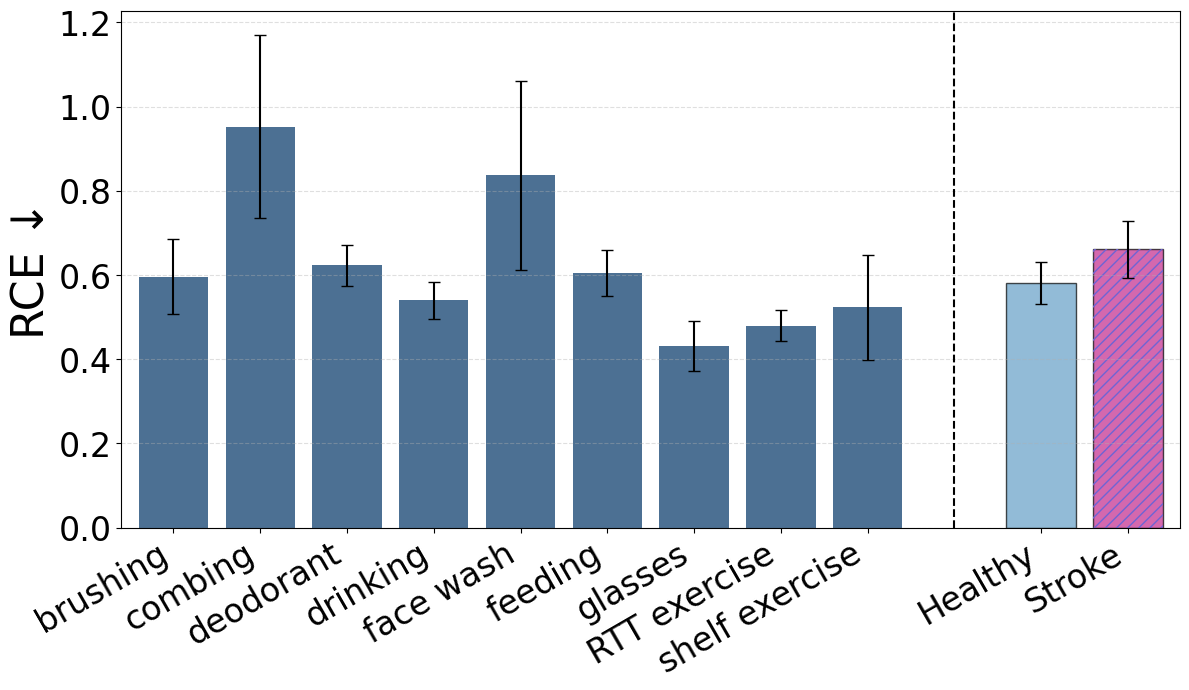

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_scores_by_activity_and_cohort(df_samples: pd.DataFrame):
    """
    Combined plot of mean ± SEM for Edit Score and Action Error Rate (AER),
    showing activities (alphabetically sorted) and stroke cohorts.

    Expects columns:
      - 'activity_cleaned'
      - 'edit_score'
      - 'action_error_rate'
      - 'stroke' (bool)

    Stroke == True  → "Mild/Moderate"
    Stroke == False → "Control"
    """
    df = df_samples.copy()
    df["cohort"] = df["stroke"].map({True: "Stroke", False: "Healthy"})

    # --- Group 1: by activity ---
    act_grouped = df.groupby("activity_cleaned")[["edit_score", "action_error_rate", "relative_counting_error"]]
    act_stats = act_grouped.agg(["mean", "std", "count"])
    act_stats.columns = ["_".join(c) for c in act_stats.columns]
    # act_stats = act_stats.sort_index()  # alphabetical
    act_stats = act_stats.sort_index(key=lambda s: s.str.lower().str.strip())


    # --- Group 2: by cohort ---
    coh_grouped = df.groupby("cohort")[["edit_score", "action_error_rate", "relative_counting_error"]]
    coh_stats = coh_grouped.agg(["mean", "std", "count"])
    coh_stats.columns = ["_".join(c) for c in coh_stats.columns]

    # --- SEM ---
    def sem(std, n):
        return std / np.sqrt(np.maximum(n, 1))

    for metric, ylabel in [
        # ("edit_score", "Edit Score"),
        # ("action_error_rate", "Action Error Rate"),
        ("relative_counting_error", "RCE ↓"),
    ]:
        fig, ax = plt.subplots(figsize=(12, 7))

        # Activities (left)
        means_act = act_stats[f"{metric}_mean"]
        errs_act = sem(act_stats[f"{metric}_std"], act_stats[f"{metric}_count"])
        x_acts = np.arange(len(means_act))
        ax.bar(x_acts, means_act, yerr=errs_act, capsize=4, alpha=0.7, color="#003366", label="Activity")

        # Add dashed separator
        sep = len(x_acts) - 0.5
        ax.axvline(sep + 0.5, color="black", linestyle="--", linewidth=1.5)

        # Cohorts (right)
        means_coh = coh_stats[f"{metric}_mean"]
        errs_coh = sem(coh_stats[f"{metric}_std"], coh_stats[f"{metric}_count"])
        x_coh = np.arange(len(means_coh)) + len(x_acts) + 1
        
        first_bar_color = "#649FC7"  # Healthy
        second_bar_colors = ["#6F64D4", "#C2288C"]  # Mild/Moderate with different styles

        ax.bar(
            x_coh[0], means_coh[0], yerr=errs_coh[0],
            capsize=4, alpha=0.7,
            color=first_bar_color, edgecolor="black", linewidth=1.0
        )

        # --- Second bar (Mild/Moderate, overlay mix) ---
        # Base violet layer
        ax.bar(
            x_coh[1], means_coh[1], yerr=errs_coh[1],
            capsize=4, alpha=0.7,
            color=second_bar_colors[1], edgecolor="black", linewidth=1.0
        )
        # Pink hatched overlay
        ax.bar(
            x_coh[1], means_coh[1],
            color="none", edgecolor=second_bar_colors[0],
            hatch="///", linewidth=0.0
        )

        # --- X-axis labels ---
        xticks = list(x_acts) + list(x_coh)
        xticklabels = list(means_act.index) + list(means_coh.index)
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels, rotation=30, ha="right")

        # --- Styling ---
        ax.set_ylabel(ylabel, fontsize=32)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.tick_params(axis="x", labelsize=24)
        ax.tick_params(axis="y", labelsize=24)
        ax.set_xlim(-0.6, x_coh[-1] + 0.6)
        plt.tight_layout()


plot_scores_by_activity_and_cohort(df_samples)
plt.savefig("./rce_breakdown.pdf", bbox_inches='tight', dpi=300)
plt.show()

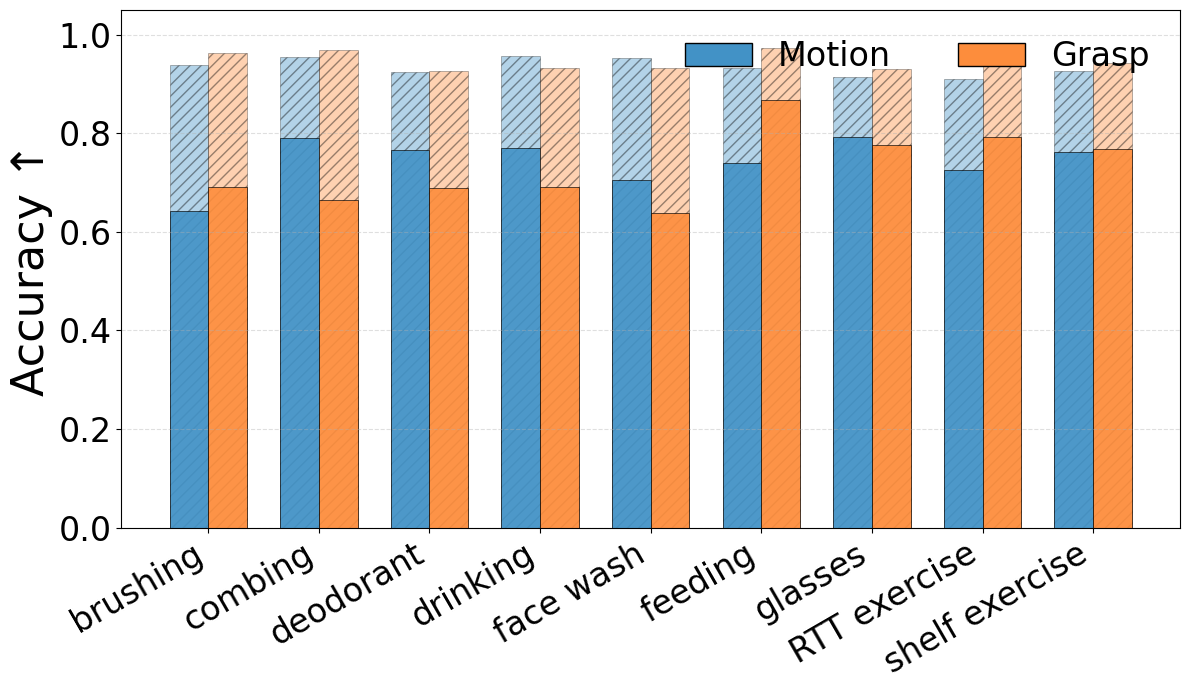

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def plot_acc_by_activity(df_samples: pd.DataFrame,
                         df_resps: pd.DataFrame):
    """
    Grouped overlaid bar chart of frame-level Accuracy by activity.
    Solid bars = omniscient baseline (center-frame GT predicting full segment).
    Hatched bars = VLM prediction accuracy.
    Both weighted by segment duration (dt) for frame-level accuracy.
    """
    df = df_resps.merge(df_samples[["id", "activity_cleaned"]], on="id", how="left")

    rows = []
    for act, g in df.groupby("activity_cleaned"):
        for signal in ["motion", "grasp"]:
            omni_col = f"{signal}_omni_frame_acc"
            vlm_col  = f"{signal}_vlm_frame_acc"
            if omni_col not in g.columns or vlm_col not in g.columns:
                continue
            mask = g[omni_col].notna() & g[vlm_col].notna()
            sub = g[mask]
            if sub.empty:
                continue
            dt = sub["dt"].astype(float)
            total_dur = dt.sum()
            if total_dur == 0:
                continue
            omni_acc = (dt * sub[omni_col]).sum() / total_dur
            vlm_acc  = (dt * sub[vlm_col]).sum() / total_dur
            rows.append({"activity": act, "signal": signal,
                         "omniscient": omni_acc, "vlm": vlm_acc})

    df_acc = pd.DataFrame(rows)
    activities = sorted(df_acc["activity"].unique(), key=str.lower)
    x = np.arange(len(activities))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 7))

    colors = {
        "motion": "#4292c6",
        "grasp":  "#fd8d3c",
    }

    for signal, offset in [("motion", -width / 2), ("grasp", width / 2)]:
        sub = df_acc[df_acc["signal"] == signal].set_index("activity").reindex(activities)

        # Solid bar (omniscient baseline) — no hatch, behind
        ax.bar(x + offset, sub["omniscient"].values, width,
               color=colors[signal], alpha=0.4, edgecolor="black", linewidth=0.5, hatch="///")
        # Hatched bar (VLM) — overlaid
        ax.bar(x + offset, sub["vlm"].values, width,
               color=colors[signal], alpha=0.9, edgecolor="black", linewidth=0.5)

    ax.set_ylabel("Accuracy \u2191", fontsize=32)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(activities, rotation=30, ha="right", fontsize=24)
    ax.tick_params(axis="y", labelsize=24)

    motion_patch = mpatches.Patch(facecolor=colors["motion"], edgecolor="black", label="Motion")
    grasp_patch  = mpatches.Patch(facecolor=colors["grasp"],  edgecolor="black", label="Grasp")
    ax.legend(handles=[motion_patch, grasp_patch], fontsize=24, loc="upper right", frameon=False, ncol=2)

    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()


plot_acc_by_activity(df_samples, df_resps)
plt.savefig("./motion_grasp_acc_by_activity.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [32]:
df_resps

,id,segment_idx,t0,t1,dt,answer_raw,motion_pred,grasp_pred,prims_window,motion_gt_middle,grasp_gt_middle,motion_gt_window,grasp_gt_window,motion_omni_frame_acc,grasp_omni_frame_acc,motion_vlm_frame_acc,grasp_vlm_frame_acc
0,S00011_RTT right side1_1,0,0.000,0.533,0.533,idle,False,False,[idle],False,False,False,False,1.000000,1.000000,1.000000,1.000000
1,S00011_RTT right side1_1,1,0.533,1.067,0.534,idle,False,False,[idle],False,False,False,False,1.000000,1.000000,1.000000,1.000000
2,S00011_RTT right side1_1,2,1.067,1.600,0.533,transport,True,True,"[idle, reach]",True,False,<NA>,False,0.624765,1.000000,0.624765,0.000000
3,S00011_RTT right side1_1,3,1.600,2.133,0.533,transport,True,True,"[reach, transport]",True,False,True,<NA>,1.000000,0.782364,1.000000,0.217636
4,S00011_RTT right side1_1,4,2.133,2.667,0.534,transport,True,True,[transport],True,True,True,True,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9059,C00029_shelf right side1_1,84,44.800,45.333,0.533,idle,False,False,[idle],False,False,False,False,1.000000,1.000000,1.000000,1.000000
9060,C00029_shelf right side1_1,85,45.333,45.867,0.534,idle,False,False,[idle],False,False,False,False,1.000000,1.000000,1.000000,1.000000
9061,C00029_shelf right side1_1,86,45.867,46.400,0.533,idle,False,False,[idle],False,False,False,False,1.000000,1.000000,1.000000,1.000000
9062,C00029_shelf right side1_1,87,46.400,46.933,0.533,idle,False,False,[idle],False,False,False,False,1.000000,1.000000,1.000000,1.000000


In [34]:
import seaborn as sns

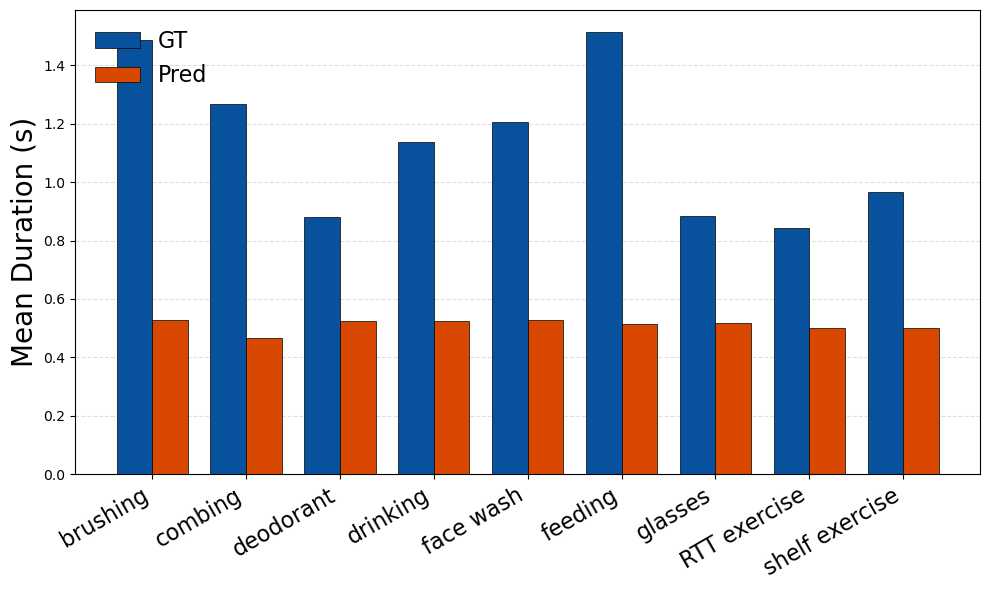

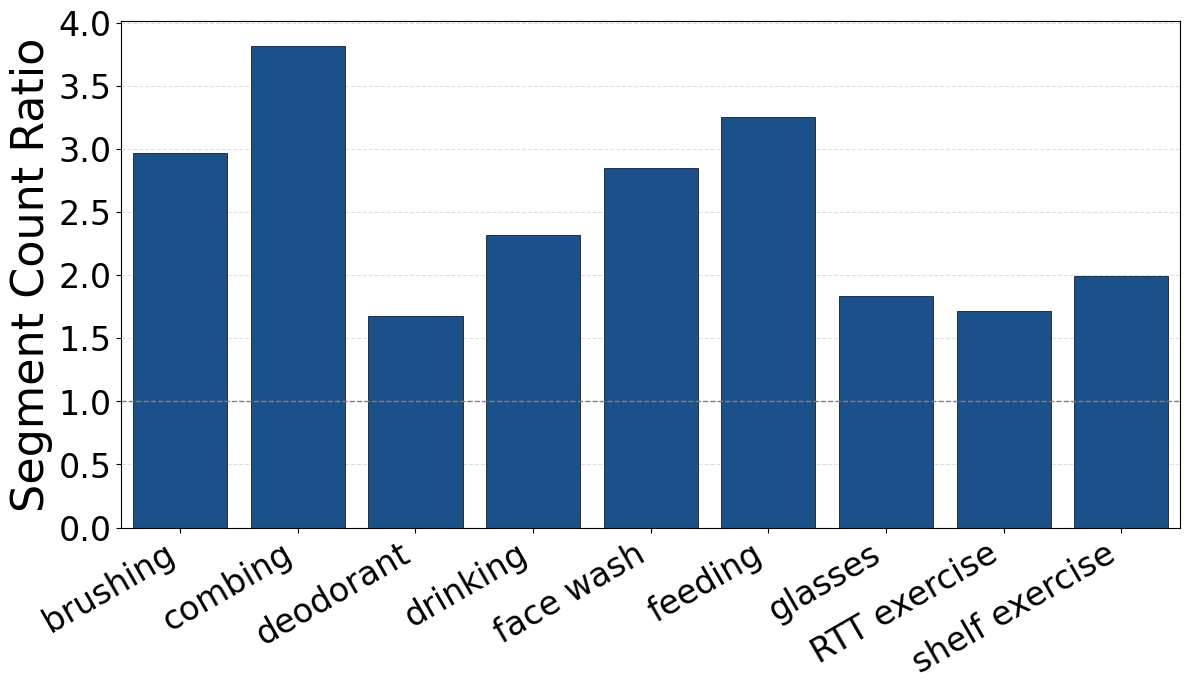

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_avg_primitive_duration(
    df_samples: pd.DataFrame,
    get_gt_prims,
    primitive: str | None = None,
    agg: str = "mean",   # {"mean","sum"}
):
    """
    Compare duration of a primitive between GT and Pred by activity_cleaned.
    If `primitive` is None/"" -> aggregate across ALL primitives using `agg`.

    df_samples must have: ['id','activity_cleaned','path_l','filtered_resps','duration_s']
    get_gt_prims(path_l) -> (prims, times) with sorted `times`.
    """

    def durations_from_prims(prims, times, dur_end):
        """Return dict {primitive: [durations...]} for an entire video."""
        ends = list(times[1:]) + [dur_end]
        durs = {}
        for p, t0, t1 in zip(prims, times, ends):
            durs.setdefault(p, []).append(max(0.0, t1 - t0))
        return durs

    rows = []  # (activity_cleaned, source, duration)

    for _, r in df_samples.iterrows():
        act   = r.get("activity_cleaned", r.get("activity"))
        if act is None:
            continue
        T_end = float(r["duration_s"])

        # --- GT ---
        try:
            gt_prims, gt_times = get_gt_prims(r["path_l"])
            gt_durs = durations_from_prims(gt_prims, gt_times, T_end)
            if primitive:  # specific primitive
                for d in gt_durs.get(primitive, []):
                    rows.append((act, "GT", d))
            else:  # aggregate over all primitives
                for d in (d for L in gt_durs.values() for d in L):
                    rows.append((act, "GT", d))
        except Exception:
            pass

        # --- Pred (from filtered_resps "prim@time;prim@time;...") ---
        try:
            parts = [p.split("@") for p in str(r["filtered_resps"]).split(";") if "@" in p]
            if not parts:
                continue
            pred_prims = [p[0] for p in parts]
            pred_times = [float(p[1]) for p in parts]
            pred_durs  = durations_from_prims(pred_prims, pred_times, T_end)
            if primitive:
                for d in pred_durs.get(primitive, []):
                    rows.append((act, "Pred", d))
            else:
                for d in (d for L in pred_durs.values() for d in L):
                    rows.append((act, "Pred", d))
        except Exception:
            pass

    df_all = pd.DataFrame(rows, columns=["activity_cleaned","source","duration"])
    if df_all.empty:
        print(f"No data found for primitive '{primitive}' (agg='{agg}').")
        return None

    if agg not in {"mean","sum"}:
        raise ValueError("agg must be 'mean' or 'sum'")

    agg_fn = {"mean":"mean","sum":"sum"}[agg]
    df_summary = (
        df_all.groupby(["activity_cleaned","source"], as_index=False)["duration"]
        .agg(agg_fn)
        .rename(columns={"duration": f"{agg}_duration"})
    )

    # ---- STYLE MATCH: alphabetical activities (case/space-insensitive), figure, grid, labels ----
    df_summary["activity_cleaned"] = pd.Categorical(
        df_summary["activity_cleaned"],
        categories=sorted(df_summary["activity_cleaned"].unique(), key=lambda s: s.lower().strip()),
        ordered=True
    )
    df_summary = df_summary.sort_values("activity_cleaned")

    acts = df_summary["activity_cleaned"].cat.categories.tolist()
    width = 0.38
    x = np.arange(len(acts))

    # Align GT/Pred per activity
    colname = f"{agg}_duration"
    y_gt = []
    y_pr = []
    for a in acts:
        sub = df_summary[df_summary["activity_cleaned"] == a]
        y_gt.append(float(sub.loc[sub["source"] == "GT", colname].sum()))
        y_pr.append(float(sub.loc[sub["source"] == "Pred", colname].sum()))

    # Colors to match the bold tones used in your F1 plot
    color_gt   = "#08519c"  # dark blue
    color_pred = "#d94801"  # dark orange

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, y_gt,  width=width, label="GT",
            color=color_gt, edgecolor="black", linewidth=0.5)
    plt.bar(x + width/2, y_pr,  width=width, label="Pred",
            color=color_pred, edgecolor="black", linewidth=0.5)

    title_prim = primitive if primitive else "ALL primitives"
    # no x-label (match style), keep strong y-label
    plt.ylabel(f"{agg.capitalize()} Duration (s)", fontsize=20)
    plt.xlabel("")
    plt.xticks(x, acts, rotation=30, ha="right", fontsize=16)
    plt.ylim(bottom=0)
    plt.legend(frameon=False, fontsize=16, loc="upper left")

    # grid like F1
    ax = plt.gca()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()

    return df_summary


def plot_segment_count_ratio(df_samples: pd.DataFrame):
    """
    Plot average ratio (#predicted segments / #GT segments) per activity_cleaned.

    Requires columns: ['activity_cleaned', 'target', 'filtered_resps']
    """
    ratios = []
    for _, row in df_samples.iterrows():
        act = row.get("activity_cleaned", row.get("activity"))
        if act is None:
            continue
        try:
            n_gt   = sum("@" in p for p in str(row["target"]).split(";"))
            n_pred = sum("@" in p for p in str(row["filtered_resps"]).split(";"))
            if n_gt > 0:
                ratios.append({"activity_cleaned": act, "ratio": n_pred / n_gt})
        except Exception:
            continue

    df_ratio = pd.DataFrame(ratios)
    if df_ratio.empty:
        print("No valid data to compute segment count ratios.")
        return

    df_summary = (
        df_ratio.groupby("activity_cleaned", as_index=False)["ratio"]
        .mean()
    )

    # ---- STYLE MATCH: alphabetical activities (case/space-insensitive), figure, grid, labels ----
    df_summary["activity_cleaned"] = pd.Categorical(
        df_summary["activity_cleaned"],
        categories=sorted(df_summary["activity_cleaned"].unique(), key=lambda s: s.lower().strip()),
        ordered=True
    )
    df_summary = df_summary.sort_values("activity_cleaned")

    plt.figure(figsize=(12, 7))
    ax = sns.barplot(
        data=df_summary, x="activity_cleaned", y="ratio",
        color="#08519c",  # match F1's dark blue family
        edgecolor="black", linewidth=0.5
    )

    # style & annotations (match F1)
    plt.axhline(1.0, color="gray", linestyle="--", lw=1)
    plt.ylabel("Segment Count Ratio", fontsize=32)
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right", fontsize=24)
    plt.yticks(fontsize=24)

    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()

    return df_summary


# Example:
# for primitive in ['idle', 'reach', 'transport', 'reposition', 'stabilize']:
_ = plot_avg_primitive_duration(df_samples, get_gt_prims)
# plt.show()
_ = plot_segment_count_ratio(df_samples)
plt.savefig("./segment_count_ratio.pdf", bbox_inches='tight', dpi=300)
plt.show()